In [2]:

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras import models

from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow Version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# ============================================================
# HYPERPARAMETERS
# ============================================================

IMAGE_SIZE = 256
BATCH_SIZE = 16
LR = 1e-4
EPOCHS = 50

AUTOTUNE = tf.data.AUTOTUNE

In [4]:
# ============================================================
# DATASET PATHS
# ============================================================

PROJECT_PATH = (
    "/kaggle/input/datasets/"
    "mohansai7815/"
    "isic-256-dataset-zip/"
    "content/resized_dataset"
)

IMAGE_PATH = os.path.join(PROJECT_PATH, "images")
MASK_PATH = os.path.join(PROJECT_PATH, "masks")

print("Images:", len(os.listdir(IMAGE_PATH)))
print("Masks :", len(os.listdir(MASK_PATH)))

Images: 2594
Masks : 2594


In [5]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

images = sorted(os.listdir(IMAGE_PATH))

train_images, temp_images = train_test_split(
    images,
    test_size=0.20,
    random_state=SEED
)

val_images, test_images = train_test_split(
    temp_images,
    test_size=0.50,
    random_state=SEED
)

print("Train:", len(train_images))
print("Val  :", len(val_images))
print("Test :", len(test_images))

Train: 2075
Val  : 259
Test : 260


In [6]:
# ============================================================
# CREATE DATAFRAMES
# ============================================================

def create_dataframe(image_list):
    data = []

    for image_name in image_list:
        image_path = os.path.join(IMAGE_PATH, image_name)

        mask_name = image_name.replace(
            ".jpg",
            "_segmentation.png"
        )

        mask_path = os.path.join(
            MASK_PATH,
            mask_name
        )

        data.append([image_path, mask_path])

    return pd.DataFrame(
        data,
        columns=["image", "mask"]
    )

train_df = create_dataframe(train_images)
val_df = create_dataframe(val_images)
test_df = create_dataframe(test_images)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(2075, 2)
(259, 2)
(260, 2)


In [7]:
# ============================================================
# LOAD AND PREPROCESS DATA
# ============================================================

def read_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(
        image,
        (IMAGE_SIZE, IMAGE_SIZE)
    )

    image = tf.cast(image, tf.float32) / 255.0

    return image


def read_mask(mask_path):
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)

    mask = tf.image.resize(
        mask,
        (IMAGE_SIZE, IMAGE_SIZE)
    )

    mask = tf.cast(mask, tf.float32) / 255.0

    return mask

In [8]:
# ============================================================
# TF.DATA PIPELINE
# ============================================================

def load_data(image_path, mask_path):
    image = read_image(image_path)
    mask = read_mask(mask_path)

    return image, mask


def create_dataset(df, batch_size):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            df["image"].values,
            df["mask"].values
        )
    )

    dataset = dataset.map(
        load_data,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(batch_size)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [9]:
# ============================================================
# CREATE DATASETS
# ============================================================

train_dataset = create_dataset(
    train_df,
    BATCH_SIZE
)

val_dataset = create_dataset(
    val_df,
    BATCH_SIZE
)

test_dataset = create_dataset(
    test_df,
    BATCH_SIZE
)

print(train_dataset)
print(val_dataset)
print(test_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None))>


I0000 00:00:1788929847.936582      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788929847.939696      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [10]:
# ============================================================
# VERIFY DATASET SHAPES
# ============================================================

for images, masks in train_dataset.take(1):
    print("Image Batch Shape:", images.shape)
    print("Mask Batch Shape :", masks.shape)

Image Batch Shape: (16, 256, 256, 3)
Mask Batch Shape : (16, 256, 256, 1)


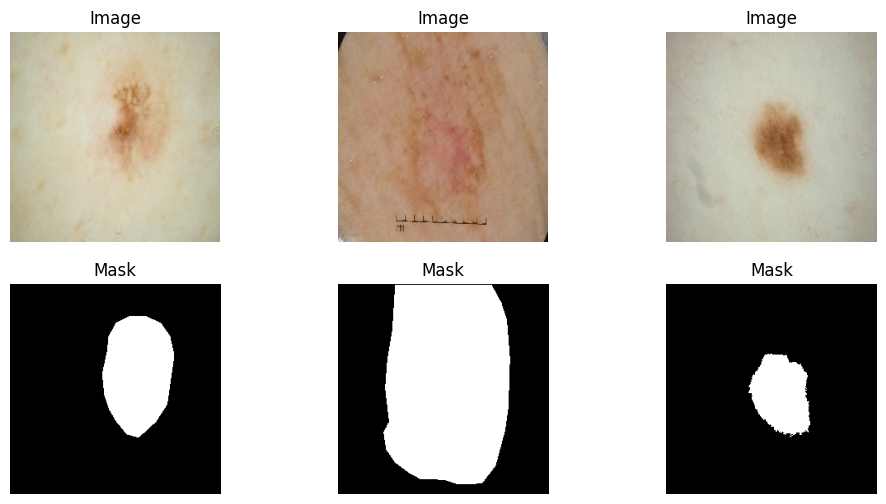

In [11]:
# ============================================================
# VISUALIZE TRAINING SAMPLES
# ============================================================

for images, masks in train_dataset.take(1):

    plt.figure(figsize=(12, 6))

    for i in range(3):

        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i])
        plt.axis("off")
        plt.title("Image")

        plt.subplot(2, 3, i + 4)
        plt.imshow(
            tf.squeeze(masks[i]),
            cmap="gray"
        )
        plt.axis("off")
        plt.title("Mask")

    plt.show()

## U-NET MODEL

In [12]:
# ============================================================
# CONVOLUTION BLOCK
# ============================================================

def conv_block(inputs, filters):

    x = layers.Conv2D(
        filters,
        3,
        padding="same"
    )(inputs)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        filters,
        3,
        padding="same"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    return x

In [13]:
# ============================================================
# ENCODER BLOCK
# ============================================================

def encoder_block(inputs, filters):

    x = conv_block(inputs, filters)

    p = layers.MaxPooling2D(
        (2, 2)
    )(x)

    return x, p

In [14]:
# ============================================================
# DECODER BLOCK
# ============================================================

def decoder_block(
    inputs,
    skip_features,
    filters
):

    x = layers.Conv2DTranspose(
        filters,
        2,
        strides=2,
        padding="same"
    )(inputs)

    x = layers.Concatenate()(
        [x, skip_features]
    )

    x = conv_block(x, filters)

    return x

In [15]:
# ============================================================
# U-NET MODEL
# ============================================================

def build_unet(input_shape=(256, 256, 3)):

    inputs = layers.Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # Bottleneck
    b1 = conv_block(p4, 1024)

    # Decoder
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = layers.Conv2D(
        1,
        1,
        activation="sigmoid"
    )(d4)

    model = models.Model(
        inputs,
        outputs,
        name="U_Net"
    )

    return model

In [16]:
# ============================================================
# CREATE MODEL
# ============================================================

model = build_unet()

model.summary()

Model: "U_Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ re_lu_2[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [17]:
# ============================================================
# DICE METRIC
# ============================================================

def dice_coef(y_true, y_pred):

    smooth = 1e-7

    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(
        y_true * y_pred
    )

    return (
        2.0 * intersection + smooth
    ) / (
        tf.reduce_sum(y_true)
        + tf.reduce_sum(y_pred)
        + smooth
    )

# ============================================================
# IOU METRIC
# ============================================================

def iou(y_true, y_pred):

    smooth = 1e-7

    intersection = tf.reduce_sum(
        y_true * y_pred
    )

    union = (
        tf.reduce_sum(y_true)
        + tf.reduce_sum(y_pred)
        - intersection
    )

    return (
        intersection + smooth
    ) / (
        union + smooth
    )

In [18]:
# ============================================================
# DICE LOSS
# ============================================================

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

# ============================================================
# BCE + DICE LOSS
# ============================================================

def bce_dice_loss(y_true, y_pred):

    bce = tf.keras.losses.binary_crossentropy(
        y_true,
        y_pred
    )

    dice = dice_loss(
        y_true,
        y_pred
    )

    return bce + dice



In [19]:
# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LR
    ),
    loss=bce_dice_loss,
    metrics=[
        dice_coef,
        iou
    ]
)

In [20]:
# ============================================================
# CALLBACKS
# ============================================================

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "best_unet.keras",
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    )
]

In [21]:
# ============================================================
# TRAIN MODEL
# ============================================================

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50


2026-09-09 04:58:06.673385: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 04:58:06.904633: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 04:58:15.727525: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 04:58:16.032367: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv (f32[16,128,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,128,128,128]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01

129/130 ━━━━━━━━━━━━━━━━━━━━ 0s 814ms/step - dice_coef: 0.4446 - iou: 0.2898 - loss: 1.2329

2026-09-09 05:00:55.693942: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 05:00:55.923492: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 05:00:57.110686: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 05:00:57.420500: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 05:01:08.612942: E external/local_xla/xla/stream_

130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_coef: 0.4451 - iou: 0.2903 - loss: 1.2309   

2026-09-09 05:02:04.730534: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 05:02:04.951299: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 05:02:05.821645: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 05:02:06.119418: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 05:02:12.317192: E external/local_xla/xla/stream_


Epoch 1: val_dice_coef improved from None to 0.26482, saving model to best_unet.keras

Epoch 1: finished saving model to best_unet.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - dice_coef: 0.5060 - iou: 0.3438 - loss: 0.9785 - val_dice_coef: 0.2648 - val_iou: 0.1533 - val_loss: 1.2993 - learning_rate: 1.0000e-04
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 815ms/step - dice_coef: 0.6013 - iou: 0.4324 - loss: 0.6999
Epoch 2: val_dice_coef did not improve from 0.26482
130/130 ━━━━━━━━━━━━━━━━━━━━ 111s 855ms/step - dice_coef: 0.6163 - iou: 0.4485 - loss: 0.6736 - val_dice_coef: 0.2548 - val_iou: 0.1468 - val_loss: 1.2604 - learning_rate: 1.0000e-04
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 814ms/step - dice_coef: 0.6552 - iou: 0.4895 - loss: 0.5915
Epoch 3: val_dice_coef improved from 0.26482 to 0.59482, saving model to best_unet.keras

Epoch 3: finished saving model to best_unet.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 113s 866ms/step - dice_coef: 0.6634 - iou: 0.4994 - loss: 0.5813 - val_d

In [22]:
# ============================================================
# LOAD BEST MODEL
# ============================================================

best_model = tf.keras.models.load_model(
    "best_unet.keras",
    custom_objects={
        "bce_dice_loss": bce_dice_loss,
        "dice_coef": dice_coef,
        "iou": iou
    }
)

In [23]:
# ============================================================
# TEST EVALUATION
# ============================================================

results = best_model.evaluate(
    test_dataset,
    verbose=1
)

print(results)

16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - dice_coef: 0.8605 - iou: 0.7561 - loss: 0.2992

2026-09-09 05:49:14.462978: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 05:49:14.685082: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 05:49:15.624633: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 05:49:15.924025: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 05:49:23.000860: E external/local_xla/xla/stream_

17/17 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - dice_coef: 0.8589 - iou: 0.7542 - loss: 0.3208
[0.3207533657550812, 0.858871340751648, 0.7541680932044983]


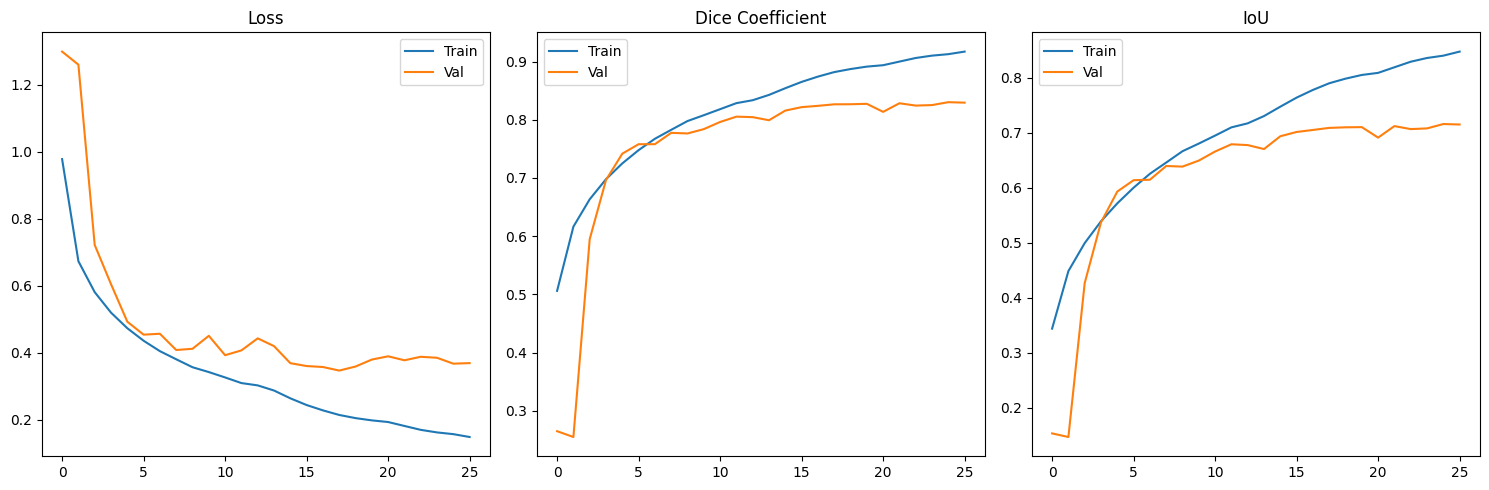

In [24]:
# ============================================================
# TRAINING CURVES
# ============================================================

plt.figure(figsize=(15,5))

# Loss
plt.subplot(1,3,1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()

# Dice
plt.subplot(1,3,2)
plt.plot(history.history["dice_coef"], label="Train")
plt.plot(history.history["val_dice_coef"], label="Val")
plt.title("Dice Coefficient")
plt.legend()

# IoU
plt.subplot(1,3,3)
plt.plot(history.history["iou"], label="Train")
plt.plot(history.history["val_iou"], label="Val")
plt.title("IoU")
plt.legend()

plt.tight_layout()
plt.show()

2026-09-09 05:49:29.845227: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 05:49:30.068730: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 05:49:31.074794: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 05:49:31.377252: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 05:49:38.568423: E external/local_xla/xla/stream_

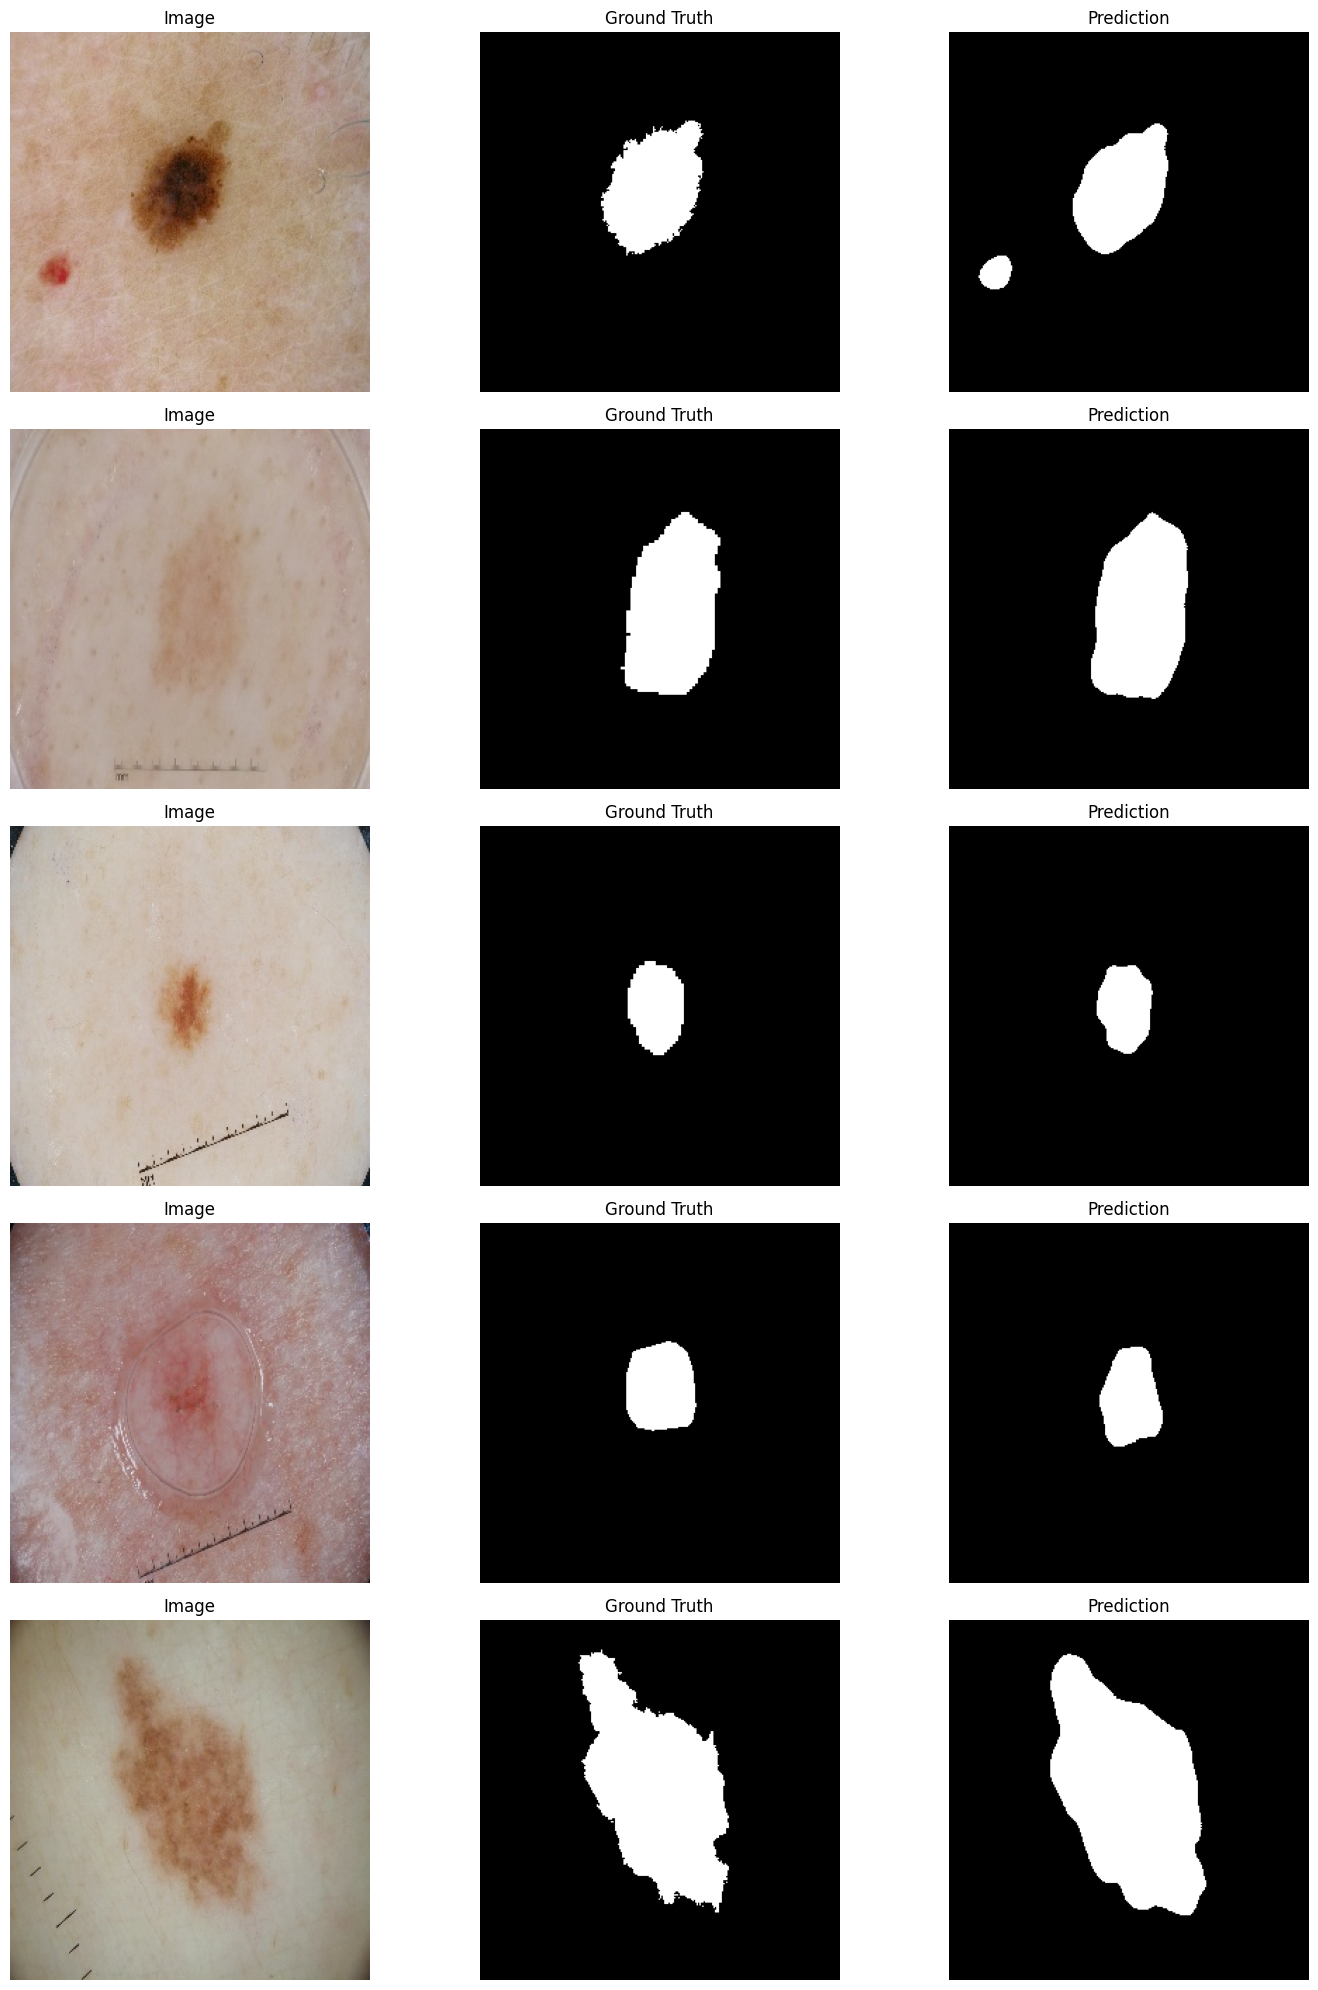

In [25]:
# ============================================================
# VISUALIZE PREDICTIONS
# ============================================================

sample_batch = next(iter(test_dataset))

images, masks = sample_batch

# Predict first 5 images
pred_masks = best_model.predict(images[:5], verbose=0)

# Threshold predictions
pred_masks = (pred_masks > 0.5).astype(np.float32)

plt.figure(figsize=(15, 20))

for i in range(5):

    # Original Image
    plt.subplot(5, 3, 3*i + 1)
    plt.imshow(images[i].numpy())
    plt.title("Image")
    plt.axis("off")

    # Ground Truth Mask
    plt.subplot(5, 3, 3*i + 2)
    plt.imshow(tf.squeeze(masks[i]).numpy(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # Predicted Mask
    plt.subplot(5, 3, 3*i + 3)
    plt.imshow(pred_masks[i, :, :, 0], cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()